# Générateur de contenu personnalisé basé sur l'IA

Ce projet simule un système de recommandation capable de générer des suggestions personnalisées (livres) en se basant sur les profils et préférences des utilisateurs. Nous allons suivre les étapes suivantes :

1. Définir les profils et les préférences des utilisateurs.
2. Générer et analyser des données (utilisateurs, activités, intérêts).
3. Créer un moteur de recommandation.
4. Visualiser les informations.


## 1. Définir les profils et les préférences des utilisateurs

In [10]:
import pandas as pd
import numpy as np

# Définir les attributs des utilisateurs et leurs préférences
num_users = 100

# Créer des noms d'utilisateurs génériques
users = [f'User_{i+1}' for i in range(num_users)]

# Définir des catégories d'intérêts possibles
interests_categories = [
    'Fiction', 'Science-Fiction', 'Fantasy', 'Romance', 'Thriller',
    'Biographie', 'Histoire', 'Science', 'Technologie', 'Cuisine',
    'Voyage', 'Développement Personnel', 'Poésie', 'Art', 'Jeunesse'
]

# Générer aléatoirement les intérêts pour chaque utilisateur
# Chaque utilisateur aura un nombre aléatoire d'intérêts (entre 1 et 5)
user_interests = []
for _ in range(num_users):
    num_random_interests = np.random.randint(1, 6) # 1 to 5 interests
    selected_interests = np.random.choice(interests_categories, num_random_interests, replace=False).tolist()
    user_interests.append(selected_interests)

# Créer un DataFrame pour les profils utilisateurs
user_profiles_df = pd.DataFrame({
    'UserID': users,
    'Age': np.random.randint(18, 65, num_users),
    'Gender': np.random.choice(['Male', 'Female', 'Other'], num_users),
    'Location': np.random.choice(['Paris', 'Lyon', 'Marseille', 'Toulouse', 'Nice'], num_users),
    'Interests': user_interests
})

print("Profils utilisateurs générés :")
display(user_profiles_df.head())


Profils utilisateurs générés :


,UserID,Age,Gender,Location,Interests
0,User_1,57,Male,Lyon,"[Poésie, Histoire, Science, Voyage, Cuisine]"
1,User_2,63,Female,Marseille,"[Science-Fiction, Thriller, Biographie, Jeunesse]"
2,User_3,34,Male,Marseille,"[Science, Jeunesse, Fiction]"
3,User_4,40,Male,Marseille,"[Biographie, Cuisine, Technologie, Poésie]"
4,User_5,44,Female,Toulouse,"[Science-Fiction, Biographie]"


## 2. Générer et analyser des données

### 2.1 Génération de journaux d'activité synthétiques

In [11]:
# Définir les types d'activités possibles
activity_types = ['view', 'like', 'share', 'purchase', 'skip']

# Définir les catégories de livres (basées sur les intérêts)
book_categories = interests_categories # Réutiliser les catégories d'intérêts comme catégories de livres

# Générer des journaux d'activité pour les utilisateurs
num_activities = 1000

activity_data = []
for _ in range(num_activities):
    user_id = np.random.choice(user_profiles_df['UserID'])
    activity_type = np.random.choice(activity_types, p=[0.4, 0.25, 0.15, 0.1, 0.1]) # Probabilités différentes pour les activités
    book_category = np.random.choice(book_categories)
    timestamp = pd.to_datetime('2023-01-01') + pd.to_timedelta(np.random.randint(0, 365*24*60), unit='m')

    activity_data.append({
        'UserID': user_id,
        'Timestamp': timestamp,
        'ActivityType': activity_type,
        'BookCategory': book_category
    })

activity_logs_df = pd.DataFrame(activity_data)

print("Journaux d'activité générés :")
display(activity_logs_df.head())


Journaux d'activité générés :


,UserID,Timestamp,ActivityType,BookCategory
0,User_36,2023-10-11 22:10:00,view,Art
1,User_16,2023-12-12 15:49:00,view,Fantasy
2,User_79,2023-04-10 05:47:00,like,Voyage
3,User_38,2023-01-16 08:00:00,skip,Voyage
4,User_69,2023-10-06 12:33:00,share,Jeunesse


### 2.2 Prétraitement et nettoyage des données

In [12]:
# Nettoyage de user_profiles_df
# Supprimer les doublons (basé sur UserID si unique)
user_profiles_df_cleaned = user_profiles_df.drop_duplicates(subset=['UserID'])
print(f"Nombre de profils utilisateurs après suppression des doublons : {len(user_profiles_df_cleaned)}")

# Gérer les valeurs manquantes (ici, nous n'avons pas de valeurs manquantes car les données sont synthétiques, mais c'est une bonne pratique)
# Pour les intérêts, s'il y avait des valeurs manquantes, on pourrait les remplacer par une liste vide ou un indicateur 'Non spécifié'
user_profiles_df_cleaned['Interests'] = user_profiles_df_cleaned['Interests'].apply(lambda x: x if isinstance(x, list) else [])

# Nettoyage de activity_logs_df
# Supprimer les doublons (par exemple, si une activité est enregistrée plusieurs fois avec le même timestamp pour le même utilisateur et catégorie)
activity_logs_df_cleaned = activity_logs_df.drop_duplicates(subset=['UserID', 'Timestamp', 'ActivityType', 'BookCategory'])
print(f"Nombre d'activités après suppression des doublons : {len(activity_logs_df_cleaned)}")

# Gérer les valeurs manquantes (similaire, peu probable avec données synthétiques)
activity_logs_df_cleaned.dropna(inplace=True)

print("Aperçu des profils utilisateurs nettoyés :")
display(user_profiles_df_cleaned.head())
print("Aperçu des journaux d'activité nettoyés :")
display(activity_logs_df_cleaned.head())


Nombre de profils utilisateurs après suppression des doublons : 100
Nombre d'activités après suppression des doublons : 1000
Aperçu des profils utilisateurs nettoyés :


,UserID,Age,Gender,Location,Interests
0,User_1,57,Male,Lyon,"[Poésie, Histoire, Science, Voyage, Cuisine]"
1,User_2,63,Female,Marseille,"[Science-Fiction, Thriller, Biographie, Jeunesse]"
2,User_3,34,Male,Marseille,"[Science, Jeunesse, Fiction]"
3,User_4,40,Male,Marseille,"[Biographie, Cuisine, Technologie, Poésie]"
4,User_5,44,Female,Toulouse,"[Science-Fiction, Biographie]"


Aperçu des journaux d'activité nettoyés :


,UserID,Timestamp,ActivityType,BookCategory
0,User_36,2023-10-11 22:10:00,view,Art
1,User_16,2023-12-12 15:49:00,view,Fantasy
2,User_79,2023-04-10 05:47:00,like,Voyage
3,User_38,2023-01-16 08:00:00,skip,Voyage
4,User_69,2023-10-06 12:33:00,share,Jeunesse


In [13]:
# Nettoyage de user_profiles_df
# Supprimer les doublons (basé sur UserID si unique)
user_profiles_df_cleaned = user_profiles_df.drop_duplicates(subset=['UserID'])
print(f"Nombre de profils utilisateurs après suppression des doublons : {len(user_profiles_df_cleaned)}")

# Gérer les valeurs manquantes (ici, nous n'avons pas de valeurs manquantes car les données sont synthétiques, mais c'est une bonne pratique)
# Pour les intérêts, s'il y avait des valeurs manquantes, on pourrait les remplacer par une liste vide ou un indicateur 'Non spécifié'
user_profiles_df_cleaned['Interests'] = user_profiles_df_cleaned['Interests'].apply(lambda x: x if isinstance(x, list) else [])

# Nettoyage de activity_logs_df
# Supprimer les doublons (par exemple, si une activité est enregistrée plusieurs fois avec le même timestamp pour le même utilisateur et catégorie)
activity_logs_df_cleaned = activity_logs_df.drop_duplicates(subset=['UserID', 'Timestamp', 'ActivityType', 'BookCategory'])
print(f"Nombre d'activités après suppression des doublons : {len(activity_logs_df_cleaned)}")

# Gérer les valeurs manquantes (similaire, peu probable avec données synthétiques)
activity_logs_df_cleaned.dropna(inplace=True)

print("Aperçu des profils utilisateurs nettoyés :")
display(user_profiles_df_cleaned.head())
print("Aperçu des journaux d'activité nettoyés :")
display(activity_logs_df_cleaned.head())


Nombre de profils utilisateurs après suppression des doublons : 100
Nombre d'activités après suppression des doublons : 1000
Aperçu des profils utilisateurs nettoyés :


,UserID,Age,Gender,Location,Interests
0,User_1,57,Male,Lyon,"[Poésie, Histoire, Science, Voyage, Cuisine]"
1,User_2,63,Female,Marseille,"[Science-Fiction, Thriller, Biographie, Jeunesse]"
2,User_3,34,Male,Marseille,"[Science, Jeunesse, Fiction]"
3,User_4,40,Male,Marseille,"[Biographie, Cuisine, Technologie, Poésie]"
4,User_5,44,Female,Toulouse,"[Science-Fiction, Biographie]"


Aperçu des journaux d'activité nettoyés :


,UserID,Timestamp,ActivityType,BookCategory
0,User_36,2023-10-11 22:10:00,view,Art
1,User_16,2023-12-12 15:49:00,view,Fantasy
2,User_79,2023-04-10 05:47:00,like,Voyage
3,User_38,2023-01-16 08:00:00,skip,Voyage
4,User_69,2023-10-06 12:33:00,share,Jeunesse


### 2.3 Analyse exploratoire des données (EDA)

#### Distribution des centres d'intérêt des utilisateurs

C:\Users\meles\AppData\Local\Temp\ipykernel_26572\788553361.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=interests_counts.index, y=interests_counts.values, palette='viridis')


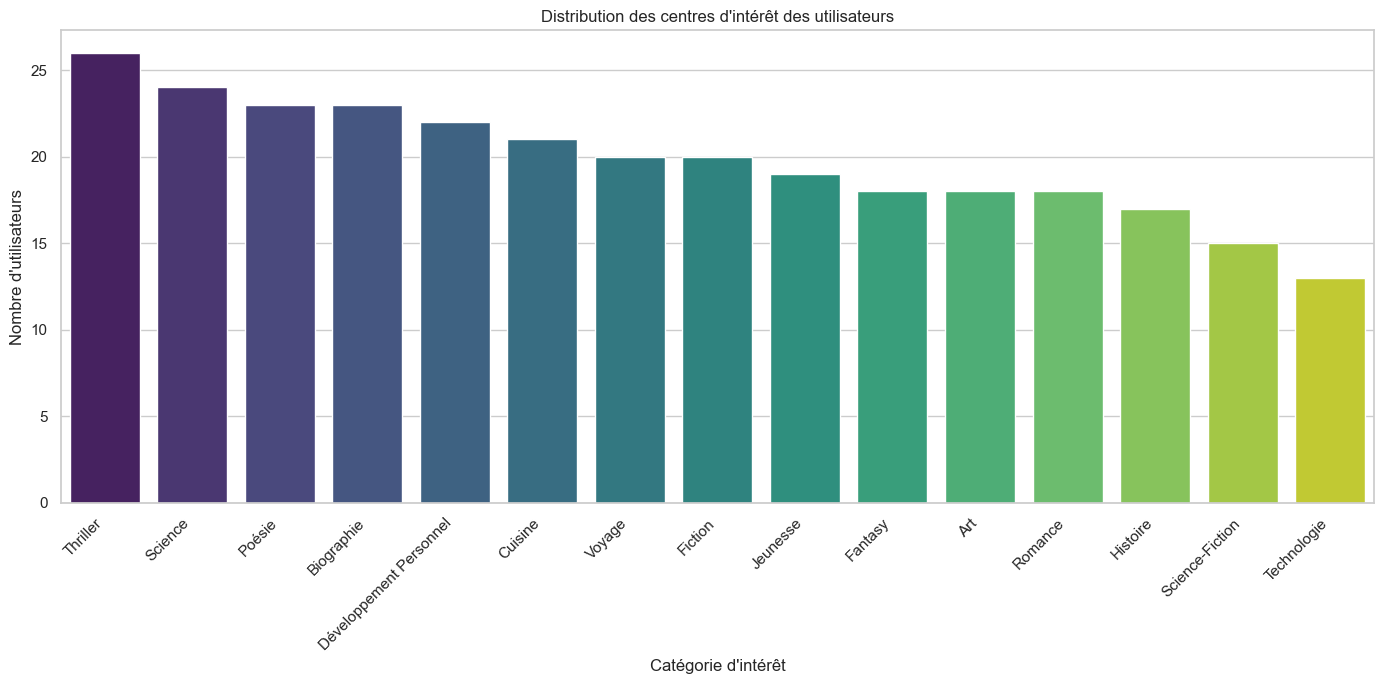

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.rcParams['figure.figsize'] = (12, 7)
sns.set_theme(style='whitegrid')

# Aplatir la liste des intérêts pour compter la fréquence de chaque catégorie
all_interests = [interest for sublist in user_profiles_df_cleaned['Interests'] for interest in sublist]

interests_counts = pd.Series(all_interests).value_counts()

plt.figure(figsize=(14, 7))
sns.barplot(x=interests_counts.index, y=interests_counts.values, palette='viridis')
plt.title("Distribution des centres d'intérêt des utilisateurs")
plt.xlabel("Catégorie d'intérêt")
plt.ylabel("Nombre d'utilisateurs")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


C:\Users\meles\AppData\Local\Temp\ipykernel_26572\788553361.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=interests_counts.index, y=interests_counts.values, palette='viridis')


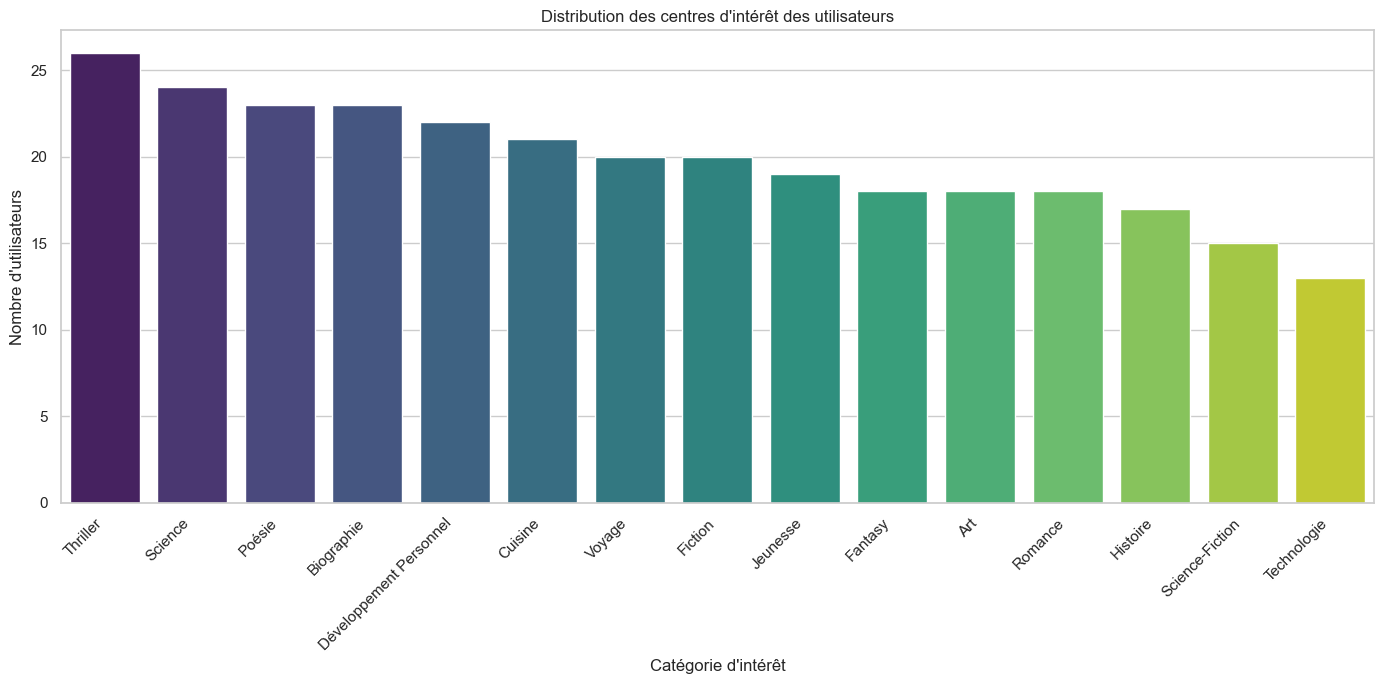

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.rcParams['figure.figsize'] = (12, 7)
sns.set_theme(style='whitegrid')

# Aplatir la liste des intérêts pour compter la fréquence de chaque catégorie
all_interests = [interest for sublist in user_profiles_df_cleaned['Interests'] for interest in sublist]

interests_counts = pd.Series(all_interests).value_counts()

plt.figure(figsize=(14, 7))
sns.barplot(x=interests_counts.index, y=interests_counts.values, palette='viridis')
plt.title("Distribution des centres d'intérêt des utilisateurs")
plt.xlabel("Catégorie d'intérêt")
plt.ylabel("Nombre d'utilisateurs")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


#### Intensité d'activité par heure

C:\Users\meles\AppData\Local\Temp\ipykernel_26572\920382548.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=activity_by_hour.index, y=activity_by_hour.values, palette='plasma')


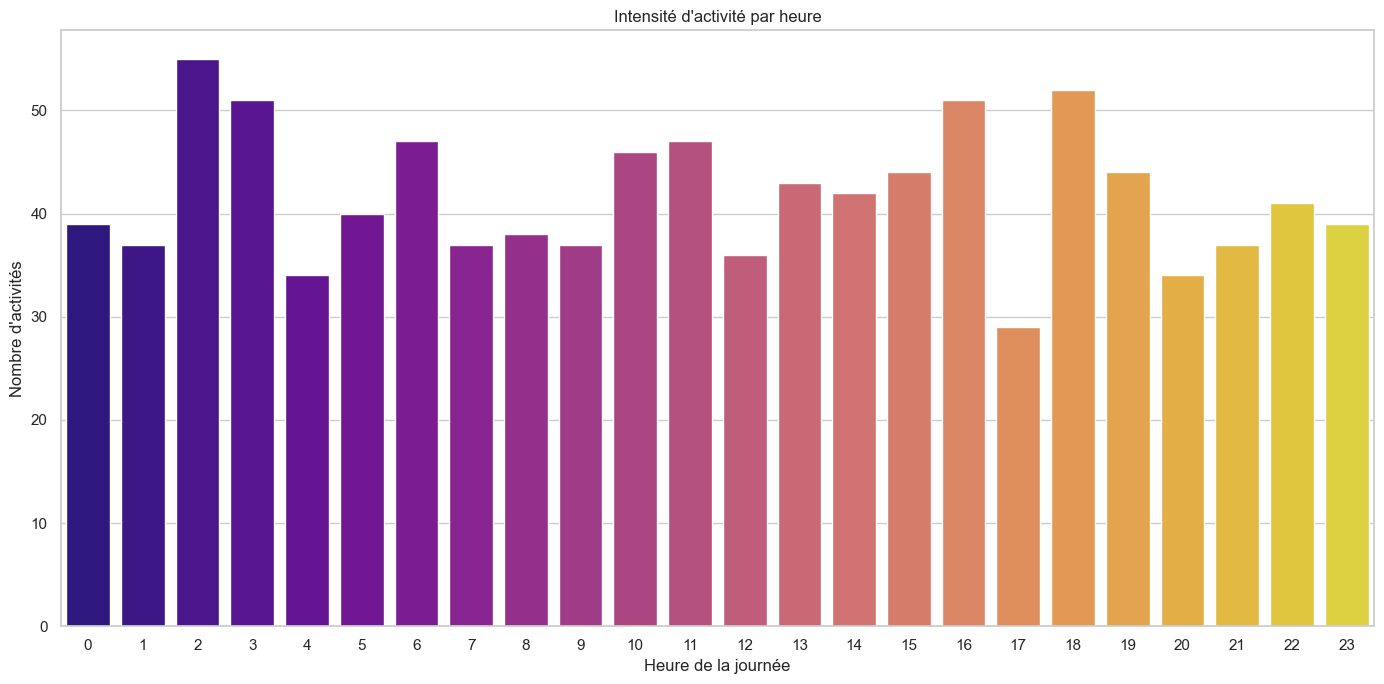

In [16]:
# Extraire l'heure de l'activité
activity_logs_df_cleaned['Hour'] = activity_logs_df_cleaned['Timestamp'].dt.hour

# Compter le nombre d'activités par heure
activity_by_hour = activity_logs_df_cleaned['Hour'].value_counts().sort_index()

plt.figure(figsize=(14, 7))
sns.barplot(x=activity_by_hour.index, y=activity_by_hour.values, palette='plasma')
plt.title("Intensité d'activité par heure")
plt.xlabel("Heure de la journée")
plt.ylabel("Nombre d'activités")
plt.xticks(range(0, 24))
plt.tight_layout()
plt.show()


C:\Users\meles\AppData\Local\Temp\ipykernel_26572\920382548.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=activity_by_hour.index, y=activity_by_hour.values, palette='plasma')


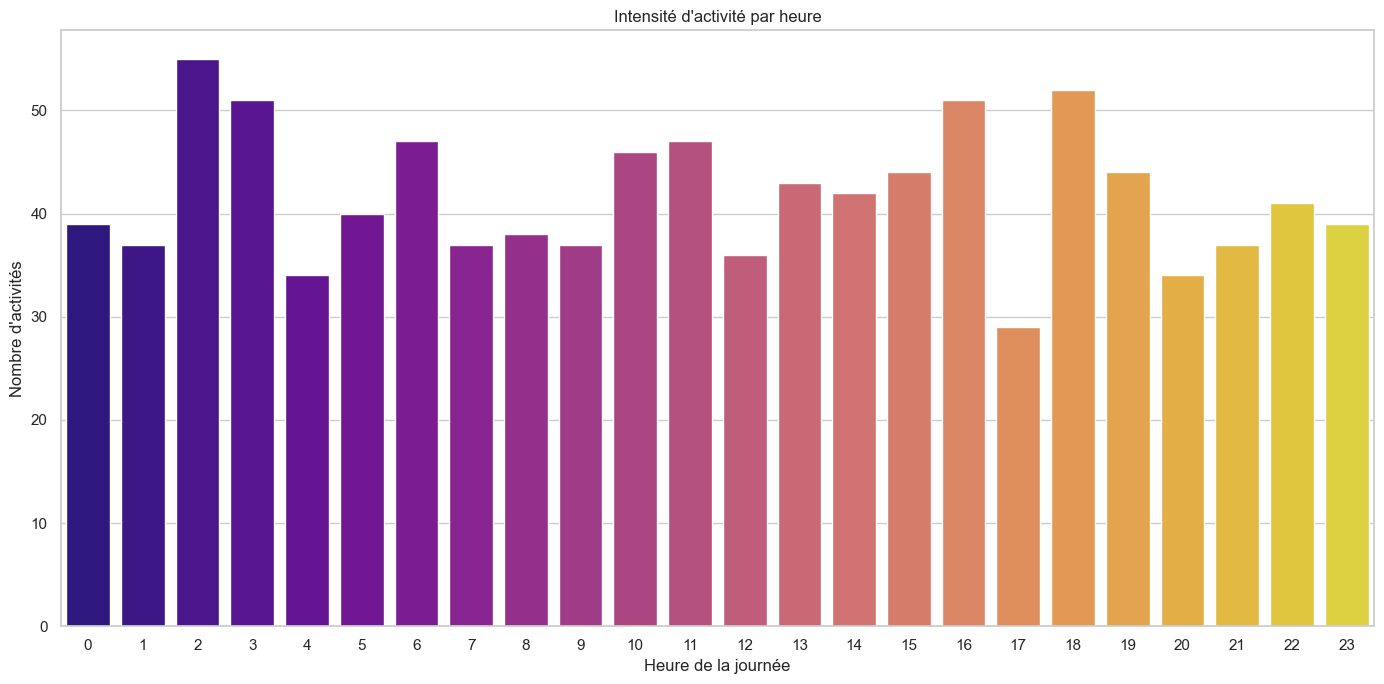

In [17]:
# Extraire l'heure de l'activité
activity_logs_df_cleaned['Hour'] = activity_logs_df_cleaned['Timestamp'].dt.hour

# Compter le nombre d'activités par heure
activity_by_hour = activity_logs_df_cleaned['Hour'].value_counts().sort_index()

plt.figure(figsize=(14, 7))
sns.barplot(x=activity_by_hour.index, y=activity_by_hour.values, palette='plasma')
plt.title("Intensité d'activité par heure")
plt.xlabel("Heure de la journée")
plt.ylabel("Nombre d'activités")
plt.xticks(range(0, 24))
plt.tight_layout()
plt.show()


#### Analyse de la distribution des centres d'intérêt avec SciPy

In [19]:
from scipy.stats import chisquare

# Nous avons déjà `interests_counts` qui contient la fréquence de chaque catégorie d'intérêt.
# Pour appliquer le test du chi-carré, nous devons définir une distribution attendue.
# Supposons une hypothèse nulle où toutes les catégories sont également préférées.

observed_frequencies = interests_counts.values

# Nombre total d'occurrences d'intérêts (pas le nombre d'utilisateurs, car un utilisateur peut avoir plusieurs intérêts)
total_interest_occurrences = observed_frequencies.sum()

# Nombre de catégories d'intérêts
num_interest_categories = len(interests_categories)

# Fréquence attendue si la distribution était uniforme
expected_frequency_per_category = total_interest_occurrences / num_interest_categories
expected_frequencies = [expected_frequency_per_category] * num_interest_categories

# Exécuter le test du chi-carré
# Assurez-vous que les `observed_frequencies` et `expected_frequencies` ont la même longueur
# et que les fréquences attendues sont > 0 (la fonction chisquare peut gérer de petites valeurs, mais l'interprétation est meilleure avec des valeurs raisonnables)

expected_frequencies = np.array(expected_frequencies)

if np.all(expected_frequencies > 0):
    chi2_stat, p_value = chisquare(f_obs=observed_frequencies, f_exp=expected_frequencies)

    print(f"Statistique du chi-carré pour les intérêts : {chi2_stat:.2f}")
    print(f"Valeur p : {p_value:.3f}")

    if p_value < 0.05:
        print("La valeur p est inférieure à 0.05, ce qui suggère que la distribution observée des intérêts est significativement différente d'une distribution uniforme.")
        print("Cela indique que certains intérêts sont préférés de manière disproportionnée par rapport à d'autres.")
    else:
        print("La valeur p est supérieure à 0.05, ce qui suggère que nous n'avons pas assez de preuves pour rejeter l'hypothèse d'une distribution uniforme des intérêts.")
else:
    print("Impossible d'effectuer le test du chi-carré : les fréquences attendues doivent être positives.")


Statistique du chi-carré pour les intérêts : 8.61
Valeur p : 0.855
La valeur p est supérieure à 0.05, ce qui suggère que nous n'avons pas assez de preuves pour rejeter l'hypothèse d'une distribution uniforme des intérêts.


In [20]:
from scipy.stats import chisquare

# Nous avons déjà `interests_counts` qui contient la fréquence de chaque catégorie d'intérêt.
# Pour appliquer le test du chi-carré, nous devons définir une distribution attendue.
# Supposons une hypothèse nulle où toutes les catégories sont également préférées.

observed_frequencies = interests_counts.values

# Nombre total d'occurrences d'intérêts (pas le nombre d'utilisateurs, car un utilisateur peut avoir plusieurs intérêts)
total_interest_occurrences = observed_frequencies.sum()

# Nombre de catégories d'intérêts
num_interest_categories = len(interests_categories)

# Fréquence attendue si la distribution était uniforme
expected_frequency_per_category = total_interest_occurrences / num_interest_categories
expected_frequencies = np.array([expected_frequency_per_category] * num_interest_categories)

# Exécuter le test du chi-carré
# Assurez-vous que les `observed_frequencies` et `expected_frequencies` ont la même longueur
# et que les fréquences attendues sont > 0 (la fonction chisquare peut gérer de petites valeurs, mais l'interprétation est meilleure avec des valeurs raisonnables)

if np.all(expected_frequencies > 0):
    chi2_stat, p_value = chisquare(f_obs=observed_frequencies, f_exp=expected_frequencies)

    print(f"Statistique du chi-carré pour les intérêts : {chi2_stat:.2f}")
    print(f"Valeur p : {p_value:.3f}")

    if p_value < 0.05:
        print("La valeur p est inférieure à 0.05, ce qui suggère que la distribution observée des intérêts est significativement différente d'une distribution uniforme.")
        print("Cela indique que certains intérêts sont préférés de manière disproportionnée par rapport à d'autres.")
    else:
        print("La valeur p est supérieure à 0.05, ce qui suggère que nous n'avons pas assez de preuves pour rejeter l'hypothèse d'une distribution uniforme des intérêts.")
else:
    print("Impossible d'effectuer le test du chi-carré : les fréquences attendues doivent être positives.")


Statistique du chi-carré pour les intérêts : 8.61
Valeur p : 0.855
La valeur p est supérieure à 0.05, ce qui suggère que nous n'avons pas assez de preuves pour rejeter l'hypothèse d'une distribution uniforme des intérêts.


#### Cartes thermiques de l'intensité d'activité par heure et par catégorie

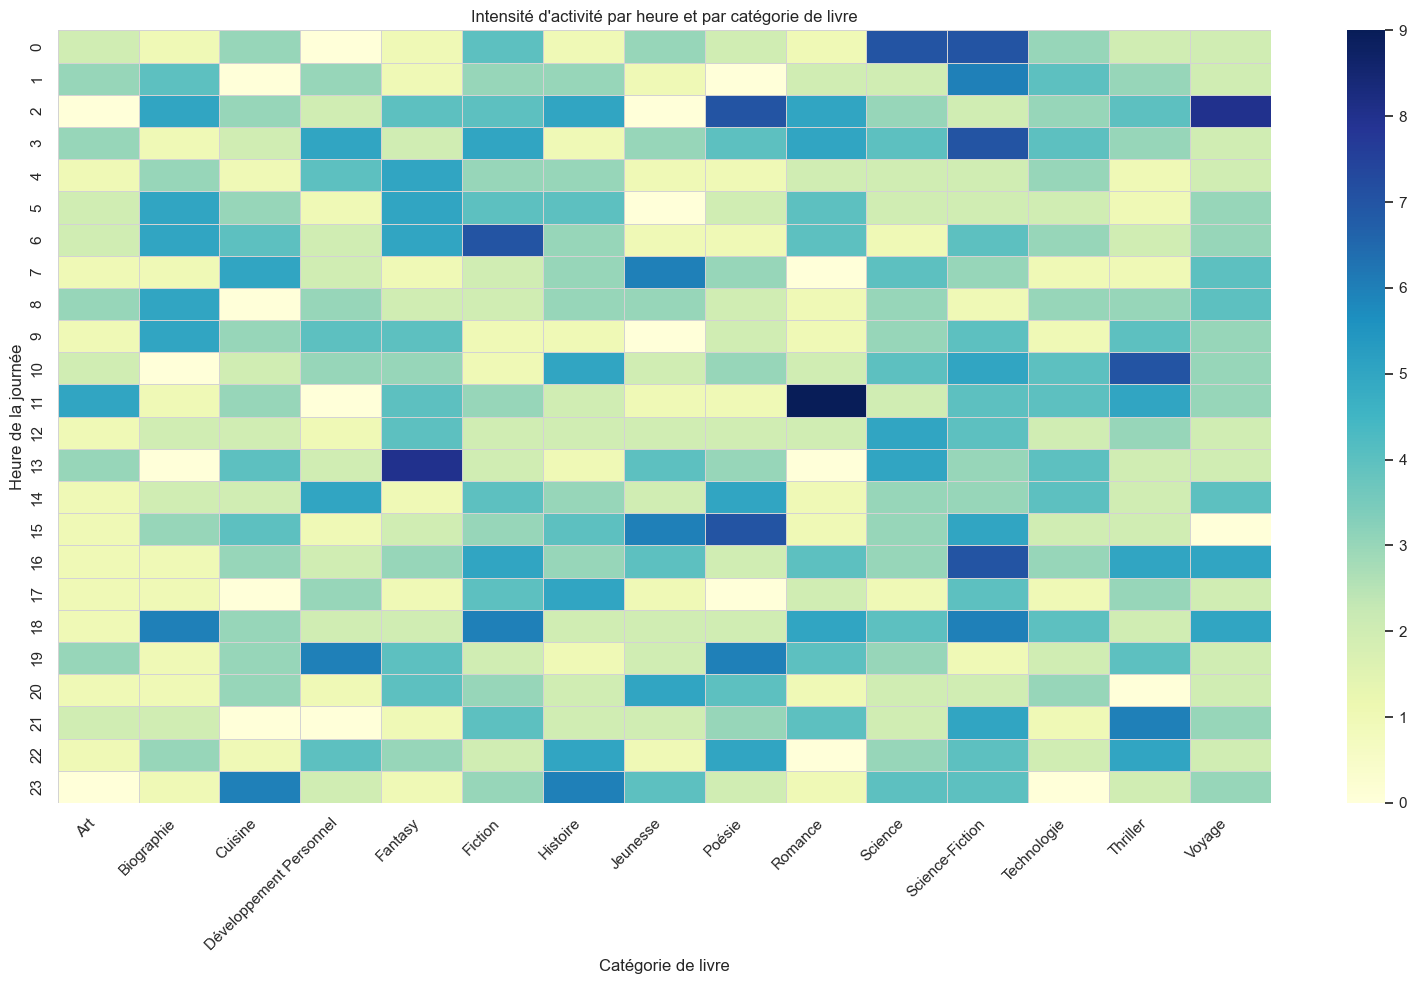

In [21]:
# Créer une colonne 'Hour' si elle n'existe pas déjà (au cas où la cellule précédente n'ait pas été exécutée)
if 'Hour' not in activity_logs_df_cleaned.columns:
    activity_logs_df_cleaned['Hour'] = activity_logs_df_cleaned['Timestamp'].dt.hour

# Pivoter les données pour créer une matrice d'intensité d'activité par heure et par catégorie
activity_heatmap_data = activity_logs_df_cleaned.groupby(['Hour', 'BookCategory']).size().unstack(fill_value=0)

plt.figure(figsize=(16, 10))
sns.heatmap(activity_heatmap_data, cmap='YlGnBu', linewidths=.5, linecolor='lightgray')
plt.title("Intensité d'activité par heure et par catégorie de livre")
plt.xlabel("Catégorie de livre")
plt.ylabel("Heure de la journée")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


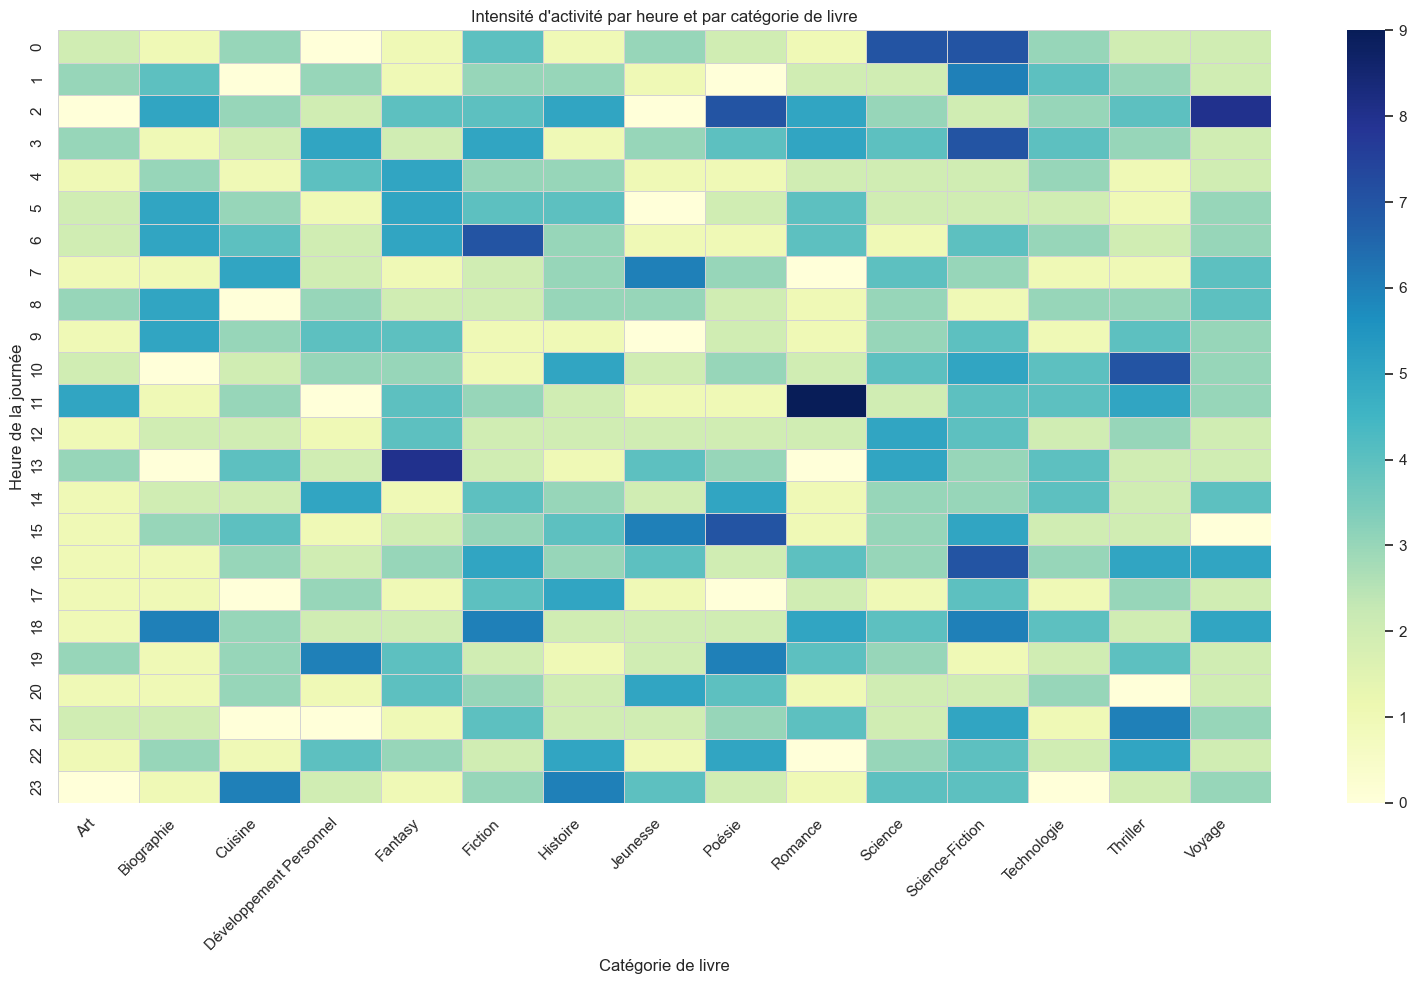

In [22]:
# Créer une colonne 'Hour' si elle n'existe pas déjà (au cas où la cellule précédente n'ait pas été exécutée)
if 'Hour' not in activity_logs_df_cleaned.columns:
    activity_logs_df_cleaned['Hour'] = activity_logs_df_cleaned['Timestamp'].dt.hour

# Pivoter les données pour créer une matrice d'intensité d'activité par heure et par catégorie
activity_heatmap_data = activity_logs_df_cleaned.groupby(['Hour', 'BookCategory']).size().unstack(fill_value=0)

plt.figure(figsize=(16, 10))
sns.heatmap(activity_heatmap_data, cmap='YlGnBu', linewidths=.5, linecolor='lightgray')
plt.title("Intensité d'activité par heure et par catégorie de livre")
plt.xlabel("Catégorie de livre")
plt.ylabel("Heure de la journée")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


## 3. Créer un moteur de recommandation

Pour créer le moteur de recommandation, nous allons définir une classe `RecommendationEngine` qui pourra :
1. Associer les préférences des utilisateurs aux catégories de contenu.
2. Générer des suggestions personnalisées en fonction des intérêts et des habitudes d'activité.
3. Adapter dynamiquement les suggestions à l'aide d'une logique conditionnelle.
4. Utiliser des métriques de similarité de SciPy pour comparer les profils utilisateurs et recommander des articles basés sur des utilisateurs similaires.

In [23]:
from scipy.spatial.distance import cosine, euclidean

class RecommendationEngine:
    def __init__(self, user_profiles_df, activity_logs_df, interests_categories):
        self.user_profiles = user_profiles_df.set_index('UserID')
        self.activity_logs = activity_logs_df
        self.interests_categories = interests_categories
        self.user_interest_vectors = self._create_user_interest_vectors()

    def _create_user_interest_vectors(self):
        """Crée des vecteurs binaires d'intérêt pour chaque utilisateur."""
        user_interest_vectors = {}
        for user_id, row in self.user_profiles.iterrows():
            vector = [1 if interest in row['Interests'] else 0 for interest in self.interests_categories]
            user_interest_vectors[user_id] = np.array(vector)
        return user_interest_vectors

    def _get_user_preferred_categories(self, user_id):
        """Récupère les catégories préférées d'un utilisateur."""
        if user_id not in self.user_profiles.index:
            return []
        return self.user_profiles.loc[user_id, 'Interests']

    def _get_popular_categories(self, top_n=5):
        """Récupère les catégories de livres les plus populaires d'après les logs d'activité."""
        return self.activity_logs['BookCategory'].value_counts().head(top_n).index.tolist()

    def get_personalized_suggestions(self, user_id, num_suggestions=3):
        """Génère des suggestions personnalisées pour un utilisateur donné.
        La logique de suggestion prend en compte les intérêts de l'utilisateur
        et les catégories populaires.
        """
        if user_id not in self.user_profiles.index:
            print(f"Utilisateur {user_id} non trouvé.")
            return []

        preferred_categories = self._get_user_preferred_categories(user_id)
        popular_categories = self._get_popular_categories(top_n=5)

        suggestions = set()

        # 1. Suggestions basées sur les intérêts directs de l'utilisateur
        for category in preferred_categories:
            suggestions.add(f"Livre de {category}")

        # 2. Suggestions basées sur les activités récentes (par exemple, ce qu'ils ont le plus "aimé" ou "acheté")
        user_recent_activity = self.activity_logs[self.activity_logs['UserID'] == user_id]
        if not user_recent_activity.empty:
            # Prioriser les catégories 'purchase' ou 'like'
            for activity_type in ['purchase', 'like']:
                recent_preferred = user_recent_activity[user_recent_activity['ActivityType'] == activity_type]['BookCategory'].value_counts().index.tolist()
                for category in recent_preferred:
                    suggestions.add(f"Livre similaire à vos récents {activity_type}s en {category}")

        # 3. Suggestions basées sur les catégories populaires si l'utilisateur a peu d'intérêts ou d'activités
        if len(suggestions) < num_suggestions and popular_categories:
            for category in popular_categories:
                suggestions.add(f"Livre populaire de {category}")

        # Logique conditionnelle simple: Si l'utilisateur est âgé, suggérer des biographies ou histoire
        user_age = self.user_profiles.loc[user_id, 'Age']
        if user_age >= 50 and 'Biographie' not in preferred_categories and 'Histoire' not in preferred_categories:
            suggestions.add("Suggestion spéciale: Découvrez une biographie fascinante ou un livre d'histoire")

        # Adapter les suggestions à la taille demandée
        return list(suggestions)[:num_suggestions]

    def find_similar_users(self, target_user_id, metric='cosine', top_n=5):
        """Trouve les utilisateurs les plus similaires à un utilisateur cible
        en utilisant la distance euclidienne ou la similarité cosinus.
        """
        if target_user_id not in self.user_interest_vectors:
            print(f"Utilisateur cible {target_user_id} non trouvé.")
            return []

        target_vector = self.user_interest_vectors[target_user_id]
        similarities = []

        for user_id, user_vector in self.user_interest_vectors.items():
            if user_id == target_user_id: # Ne pas comparer l'utilisateur à lui-même
                continue

            if metric == 'cosine':
                # Cosine similarity est 1 - cosine distance
                similarity = 1 - cosine(target_vector, user_vector)
            elif metric == 'euclidean':
                # Plus la distance euclidienne est petite, plus ils sont similaires
                similarity = -euclidean(target_vector, user_vector) # Inverser pour trier par "similarité" (distance plus petite = similarité plus grande)
            else:
                raise ValueError("Métrique non supportée. Utilisez 'cosine' ou 'euclidean'.")

            similarities.append((user_id, similarity))

        # Trier par similarité (décroissant pour cosine, croissant pour euclidean inversé)
        similarities.sort(key=lambda x: x[1], reverse=True)

        return similarities[:top_n]

    def get_recommendations_from_similar_users(self, target_user_id, num_suggestions=3, metric='cosine'):
        """Génère des recommandations basées sur les intérêts d'utilisateurs similaires."""
        similar_users = self.find_similar_users(target_user_id, metric=metric, top_n=5)
        if not similar_users:
            return self.get_personalized_suggestions(target_user_id, num_suggestions)

        # Collecter les intérêts des utilisateurs similaires
        similar_users_interests = set()
        for user_id, _ in similar_users:
            for interest in self._get_user_preferred_categories(user_id):
                similar_users_interests.add(interest)

        # Exclure les intérêts déjà connus de l'utilisateur cible
        target_user_known_interests = set(self._get_user_preferred_categories(target_user_id))
        recommended_interests = list(similar_users_interests - target_user_known_interests)

        # Si pas d'intérêts nouveaux, revenir aux suggestions personnalisées
        if not recommended_interests:
            return self.get_personalized_suggestions(target_user_id, num_suggestions)

        # Recommander les catégories les plus fréquentes parmi les utilisateurs similaires et non encore connues
        # Ou simplement les premières pour cet exemple
        suggestions = [f"Basé sur des utilisateurs similaires: Livre de {interest}" for interest in recommended_interests[:num_suggestions]]

        # Compléter avec des suggestions personnalisées si pas assez de recommandations similaires
        if len(suggestions) < num_suggestions:
            remaining_suggestions = self.get_personalized_suggestions(target_user_id, num_suggestions - len(suggestions))
            suggestions.extend(remaining_suggestions)

        return suggestions[:num_suggestions]

# Initialiser le moteur de recommandation
re_engine = RecommendationEngine(user_profiles_df_cleaned, activity_logs_df_cleaned, interests_categories)

# Exemple d'utilisation
print("\n--- Exemples de suggestions --- ")

sample_user_id = np.random.choice(user_profiles_df_cleaned['UserID'])
print(f"\nSuggestions personnalisées pour {sample_user_id} (Age: {user_profiles_df_cleaned.loc[user_profiles_df_cleaned['UserID'] == sample_user_id, 'Age'].iloc[0]}) :")
suggestions = re_engine.get_personalized_suggestions(sample_user_id, num_suggestions=5)
for s in suggestions:
    print(f"- {s}")

print(f"\nSuggestions basées sur des utilisateurs similaires pour {sample_user_id} :")
similar_user_suggestions = re_engine.get_recommendations_from_similar_users(sample_user_id, num_suggestions=5, metric='cosine')
for s in similar_user_suggestions:
    print(f"- {s}")

# Exemple avec un autre utilisateur pour illustrer la logique conditionnelle
# Trouver un utilisateur de plus de 50 ans avec peu d'intérêts en biographie/histoire
older_user_id = user_profiles_df_cleaned[
    (user_profiles_df_cleaned['Age'] >= 50) &
    (~user_profiles_df_cleaned['Interests'].apply(lambda x: 'Biographie' in x or 'Histoire' in x))
]['UserID'].sample(1).iloc[0]

print(f"\nSuggestions personnalisées pour {older_user_id} (Age: {user_profiles_df_cleaned.loc[user_profiles_df_cleaned['UserID'] == older_user_id, 'Age'].iloc[0]} ans) :")
suggestions_older = re_engine.get_personalized_suggestions(older_user_id, num_suggestions=5)
for s in suggestions_older:
    print(f"- {s}")



--- Exemples de suggestions --- 

Suggestions personnalisées pour User_66 (Age: 52) :
- Suggestion spéciale: Découvrez une biographie fascinante ou un livre d'histoire
- Livre de Jeunesse
- Livre similaire à vos récents purchases en Science-Fiction
- Livre de Fantasy
- Livre de Développement Personnel

Suggestions basées sur des utilisateurs similaires pour User_66 :
- Basé sur des utilisateurs similaires: Livre de Thriller
- Basé sur des utilisateurs similaires: Livre de Cuisine
- Basé sur des utilisateurs similaires: Livre de Art
- Basé sur des utilisateurs similaires: Livre de Science-Fiction
- Suggestion spéciale: Découvrez une biographie fascinante ou un livre d'histoire

Suggestions personnalisées pour User_66 (Age: 52 ans) :
- Suggestion spéciale: Découvrez une biographie fascinante ou un livre d'histoire
- Livre de Jeunesse
- Livre similaire à vos récents purchases en Science-Fiction
- Livre de Fantasy
- Livre de Développement Personnel


In [24]:
from scipy.spatial.distance import cosine, euclidean

class RecommendationEngine:
    def __init__(self, user_profiles_df, activity_logs_df, interests_categories):
        self.user_profiles = user_profiles_df.set_index('UserID')
        self.activity_logs = activity_logs_df
        self.interests_categories = interests_categories
        self.user_interest_vectors = self._create_user_interest_vectors()

    def _create_user_interest_vectors(self):
        """Crée des vecteurs binaires d'intérêt pour chaque utilisateur."""
        user_interest_vectors = {}
        for user_id, row in self.user_profiles.iterrows():
            vector = [1 if interest in row['Interests'] else 0 for interest in self.interests_categories]
            user_interest_vectors[user_id] = np.array(vector)
        return user_interest_vectors

    def _get_user_preferred_categories(self, user_id):
        """Récupère les catégories préférées d'un utilisateur."""
        if user_id not in self.user_profiles.index:
            return []
        return self.user_profiles.loc[user_id, 'Interests']

    def _get_popular_categories(self, top_n=5):
        """Récupère les catégories de livres les plus populaires d'après les logs d'activité."""
        return self.activity_logs['BookCategory'].value_counts().head(top_n).index.tolist()

    def get_personalized_suggestions(self, user_id, num_suggestions=3):
        """Génère des suggestions personnalisées pour un utilisateur donné.
        La logique de suggestion prend en compte les intérêts de l'utilisateur
        et les catégories populaires.
        """
        if user_id not in self.user_profiles.index:
            print(f"Utilisateur {user_id} non trouvé.")
            return []

        preferred_categories = self._get_user_preferred_categories(user_id)
        popular_categories = self._get_popular_categories(top_n=5)

        suggestions = set()

        # 1. Suggestions basées sur les intérêts directs de l'utilisateur
        for category in preferred_categories:
            suggestions.add(f"Livre de {category}")

        # 2. Suggestions basées sur les activités récentes (par exemple, ce qu'ils ont le plus "aimé" ou "acheté")
        user_recent_activity = self.activity_logs[self.activity_logs['UserID'] == user_id]
        if not user_recent_activity.empty:
            # Prioriser les catégories 'purchase' ou 'like'
            for activity_type in ['purchase', 'like']:
                recent_preferred = user_recent_activity[user_recent_activity['ActivityType'] == activity_type]['BookCategory'].value_counts().index.tolist()
                for category in recent_preferred:
                    suggestions.add(f"Livre similaire à vos récents {activity_type}s en {category}")

        # 3. Suggestions basées sur les catégories populaires si l'utilisateur a peu d'intérêts ou d'activités
        if len(suggestions) < num_suggestions and popular_categories:
            for category in popular_categories:
                suggestions.add(f"Livre populaire de {category}")

        # Logique conditionnelle simple: Si l'utilisateur est âgé, suggérer des biographies ou histoire
        user_age = self.user_profiles.loc[user_id, 'Age']
        if user_age >= 50 and 'Biographie' not in preferred_categories and 'Histoire' not in preferred_categories:
            suggestions.add("Suggestion spéciale: Découvrez une biographie fascinante ou un livre d'histoire")

        # Adapter les suggestions à la taille demandée
        return list(suggestions)[:num_suggestions]

    def find_similar_users(self, target_user_id, metric='cosine', top_n=5):
        """Trouve les utilisateurs les plus similaires à un utilisateur cible
        en utilisant la distance euclidienne ou la similarité cosinus.
        """
        if target_user_id not in self.user_interest_vectors:
            print(f"Utilisateur cible {target_user_id} non trouvé.")
            return []

        target_vector = self.user_interest_vectors[target_user_id]
        similarities = []

        for user_id, user_vector in self.user_interest_vectors.items():
            if user_id == target_user_id: # Ne pas comparer l'utilisateur à lui-même
                continue

            if metric == 'cosine':
                # Cosine similarity est 1 - cosine distance
                similarity = 1 - cosine(target_vector, user_vector)
            elif metric == 'euclidean':
                # Plus la distance euclidienne est petite, plus ils sont similaires
                similarity = -euclidean(target_vector, user_vector) # Inverser pour trier par "similarité" (distance plus petite = similarité plus grande)
            else:
                raise ValueError("Métrique non supportée. Utilisez 'cosine' ou 'euclidean'.")

            similarities.append((user_id, similarity))

        # Trier par similarité (décroissant pour cosine, croissant pour euclidean inversé)
        similarities.sort(key=lambda x: x[1], reverse=True)

        return similarities[:top_n]

    def get_recommendations_from_similar_users(self, target_user_id, num_suggestions=3, metric='cosine'):
        """Génère des recommandations basées sur les intérêts d'utilisateurs similaires."""
        similar_users = self.find_similar_users(target_user_id, metric=metric, top_n=5)
        if not similar_users:
            return self.get_personalized_suggestions(target_user_id, num_suggestions)

        # Collecter les intérêts des utilisateurs similaires
        similar_users_interests = set()
        for user_id, _ in similar_users:
            for interest in self._get_user_preferred_categories(user_id):
                similar_users_interests.add(interest)

        # Exclure les intérêts déjà connus de l'utilisateur cible
        target_user_known_interests = set(self._get_user_preferred_categories(target_user_id))
        recommended_interests = list(similar_users_interests - target_user_known_interests)

        # Si pas d'intérêts nouveaux, revenir aux suggestions personnalisées
        if not recommended_interests:
            return self.get_personalized_suggestions(target_user_id, num_suggestions)

        # Recommander les catégories les plus fréquentes parmi les utilisateurs similaires et non encore connues
        # Ou simplement les premières pour cet exemple
        suggestions = [f"Basé sur des utilisateurs similaires: Livre de {interest}" for interest in recommended_interests[:num_suggestions]]

        # Compléter avec des suggestions personnalisées si pas assez de recommandations similaires
        if len(suggestions) < num_suggestions:
            remaining_suggestions = self.get_personalized_suggestions(target_user_id, num_suggestions - len(suggestions))
            suggestions.extend(remaining_suggestions)

        return suggestions[:num_suggestions]

# Initialiser le moteur de recommandation
re_engine = RecommendationEngine(user_profiles_df_cleaned, activity_logs_df_cleaned, interests_categories)

# Exemple d'utilisation
print("\n--- Exemples de suggestions --- ")

sample_user_id = np.random.choice(user_profiles_df_cleaned['UserID'])
print(f"\nSuggestions personnalisées pour {sample_user_id} (Age: {user_profiles_df_cleaned.loc[user_profiles_df_cleaned['UserID'] == sample_user_id, 'Age'].iloc[0]}) :")
suggestions = re_engine.get_personalized_suggestions(sample_user_id, num_suggestions=5)
for s in suggestions:
    print(f"- {s}")

print(f"\nSuggestions basées sur des utilisateurs similaires pour {sample_user_id} :")
similar_user_suggestions = re_engine.get_recommendations_from_similar_users(sample_user_id, num_suggestions=5, metric='cosine')
for s in similar_user_suggestions:
    print(f"- {s}")

# Exemple avec un autre utilisateur pour illustrer la logique conditionnelle
# Trouver un utilisateur de plus de 50 ans avec peu d'intérêts en biographie/histoire
older_user_criteria = user_profiles_df_cleaned[
    (user_profiles_df_cleaned['Age'] >= 50) &
    (~user_profiles_df_cleaned['Interests'].apply(lambda x: 'Biographie' in str(x) or 'Histoire' in str(x)))
]

if not older_user_criteria.empty:
    older_user_id = older_user_criteria['UserID'].sample(1).iloc[0]
    print(f"\nSuggestions personnalisées pour {older_user_id} (Age: {user_profiles_df_cleaned.loc[user_profiles_df_cleaned['UserID'] == older_user_id, 'Age'].iloc[0]} ans) :")
    suggestions_older = re_engine.get_personalized_suggestions(older_user_id, num_suggestions=5)
    for s in suggestions_older:
        print(f"- {s}")
else:
    print("\nPas d'utilisateur de plus de 50 ans sans intérêt en biographie/histoire trouvé pour l'exemple.")



--- Exemples de suggestions --- 

Suggestions personnalisées pour User_40 (Age: 31) :
- Livre de Art
- Livre similaire à vos récents likes en Histoire
- Livre de Science
- Livre de Voyage
- Livre similaire à vos récents purchases en Fiction

Suggestions basées sur des utilisateurs similaires pour User_40 :
- Basé sur des utilisateurs similaires: Livre de Thriller
- Basé sur des utilisateurs similaires: Livre de Histoire
- Basé sur des utilisateurs similaires: Livre de Biographie
- Basé sur des utilisateurs similaires: Livre de Romance
- Basé sur des utilisateurs similaires: Livre de Poésie

Suggestions personnalisées pour User_13 (Age: 56 ans) :
- Livre de Fantasy
- Livre similaire à vos récents likes en Voyage
- Livre similaire à vos récents likes en Poésie
- Livre similaire à vos récents likes en Romance
- Suggestion spéciale: Découvrez une biographie fascinante ou un livre d'histoire


## 4. Visualiser les informations

### 4.1 Catégories les plus recommandées par segment d'utilisateurs

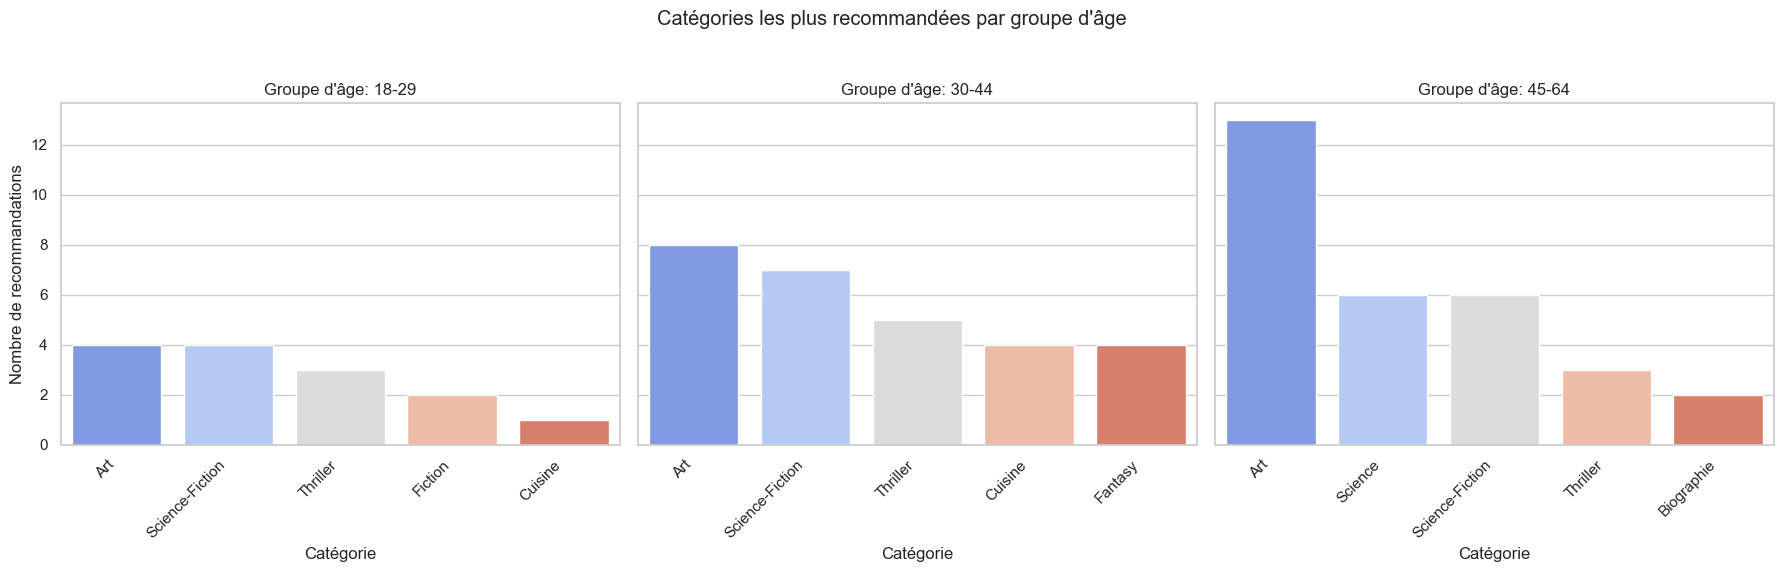

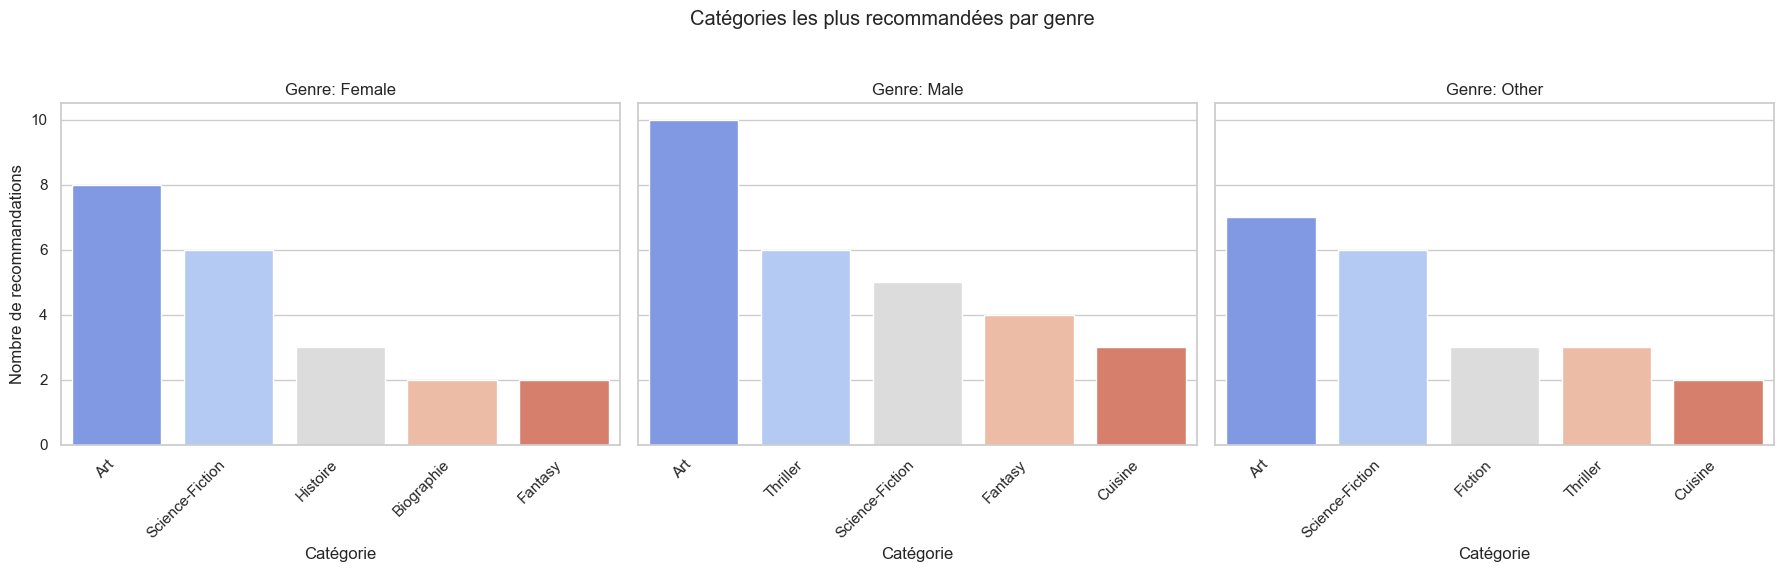

In [25]:
# Pour visualiser les catégories les plus recommandées par segment, nous devons d'abord générer des recommandations pour chaque utilisateur.
# Nous allons nous concentrer sur un segment simple, par exemple 'Gender' ou 'Age Group'.

# Créer des groupes d'âge pour une meilleure segmentation
user_profiles_df_cleaned['AgeGroup'] = pd.cut(
    user_profiles_df_cleaned['Age'],
    bins=[18, 30, 45, 65],
    labels=['18-29', '30-44', '45-64'],
    right=False
)

# Collecter les recommandations pour chaque utilisateur et chaque segment
recommendations_data = []

for user_id in user_profiles_df_cleaned['UserID']:
    user_segment_gender = user_profiles_df_cleaned.loc[user_profiles_df_cleaned['UserID'] == user_id, 'Gender'].iloc[0]
    user_segment_age_group = user_profiles_df_cleaned.loc[user_profiles_df_cleaned['UserID'] == user_id, 'AgeGroup'].iloc[0]

    # Obtenir les suggestions personnalisées (nous pouvons choisir une des méthodes, ici la principale)
    suggestions = re_engine.get_personalized_suggestions(user_id, num_suggestions=1) # Prendre la top 1 suggestion pour la simplicité

    if suggestions:
        # Extraire la catégorie du livre de la suggestion (simpliste, à adapter si les formats de suggestions varient)
        # Exemple: 'Livre de Fiction' -> 'Fiction'
        recommended_category = suggestions[0].replace('Livre de ', '').replace('Livre populaire de ', '').split(':')[0].strip()
        if 'similaire' in recommended_category:
             # Handle cases like 'Livre similaire à vos récents purchases en Fiction'
            try:
                recommended_category = recommended_category.split('en ')[1].strip()
            except IndexError:
                recommended_category = 'Autre'
        if 'spéciale' in recommended_category: # Pour la suggestion spéciale pour les âgés
            recommended_category = 'Biographie/Histoire Spéciale'

        recommendations_data.append({
            'UserID': user_id,
            'Gender': user_segment_gender,
            'AgeGroup': user_segment_age_group,
            'RecommendedCategory': recommended_category
        })

recommended_df = pd.DataFrame(recommendations_data)

# Compter les catégories recommandées par groupe d'âge
recommended_by_age_group = recommended_df.groupby('AgeGroup')['RecommendedCategory'].value_counts().unstack(fill_value=0)

# Afficher les top N recommandations par groupe d'âge
fig, axes = plt.subplots(1, len(recommended_by_age_group.index), figsize=(18, 6), sharey=True)
fig.suptitle('Catégories les plus recommandées par groupe d\'âge')

for i, (age_group, data) in enumerate(recommended_by_age_group.iterrows()):
    top_categories = data.nlargest(5) # Top 5 pour chaque groupe d'âge
    sns.barplot(x=top_categories.index, y=top_categories.values, ax=axes[i], palette='coolwarm', hue=top_categories.index, legend=False) # Modified
    axes[i].set_title(f'Groupe d\'âge: {age_group}')
    axes[i].set_xlabel('Catégorie')
    axes[i].set_xticks(range(len(top_categories.index))) # Added
    axes[i].set_xticklabels(top_categories.index, rotation=45, ha='right')
    if i == 0:
        axes[i].set_ylabel('Nombre de recommandations')
    else:
        axes[i].set_ylabel('')

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

# Répéter pour le genre
recommended_by_gender = recommended_df.groupby('Gender')['RecommendedCategory'].value_counts().unstack(fill_value=0)

fig, axes = plt.subplots(1, len(recommended_by_gender.index), figsize=(18, 6), sharey=True)
fig.suptitle('Catégories les plus recommandées par genre')

for i, (gender, data) in enumerate(recommended_by_gender.iterrows()):
    top_categories = data.nlargest(5) # Top 5 pour chaque genre
    sns.barplot(x=top_categories.index, y=top_categories.values, ax=axes[i], palette='coolwarm', hue=top_categories.index, legend=False) # Modified
    axes[i].set_title(f'Genre: {gender}')
    axes[i].set_xlabel('Catégorie')
    axes[i].set_xticks(range(len(top_categories.index))) # Added
    axes[i].set_xticklabels(top_categories.index, rotation=45, ha='right')
    if i == 0:
        axes[i].set_ylabel('Nombre de recommandations')
    else:
        axes[i].set_ylabel('')

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

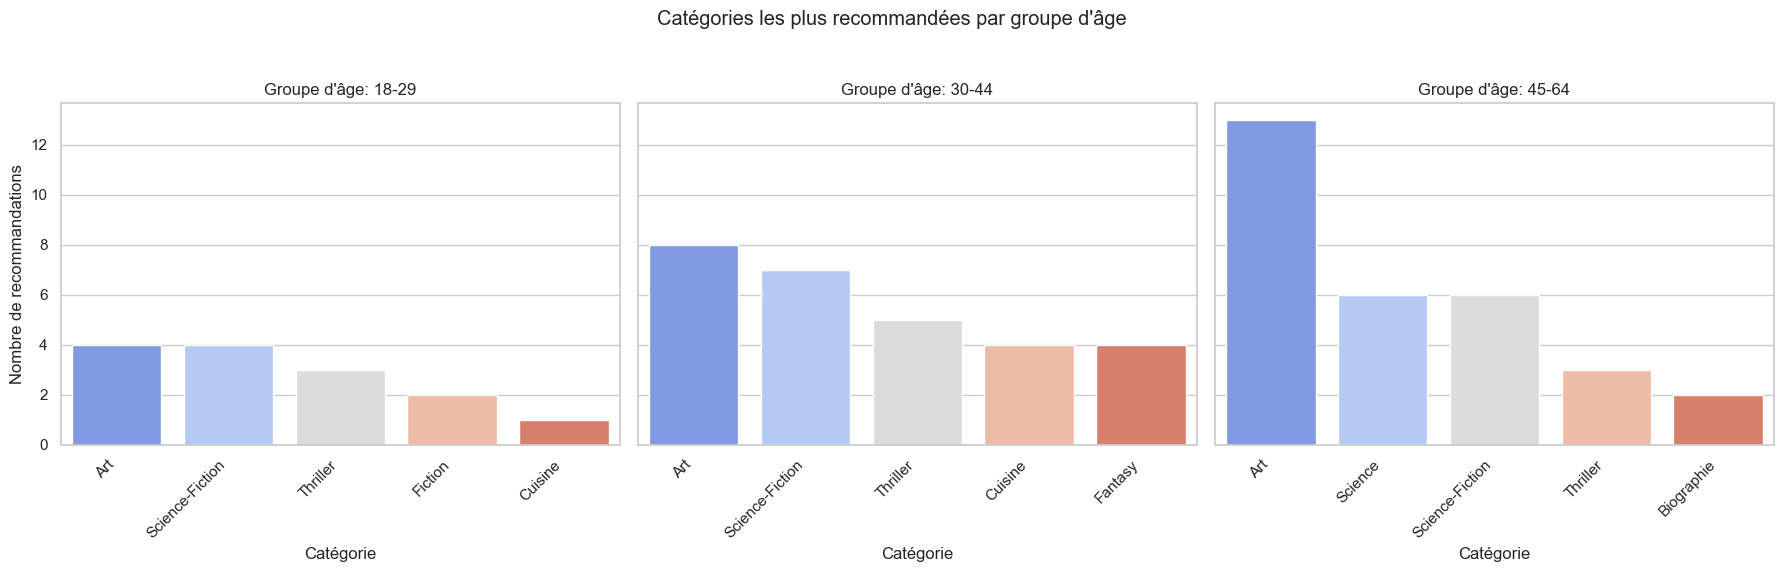

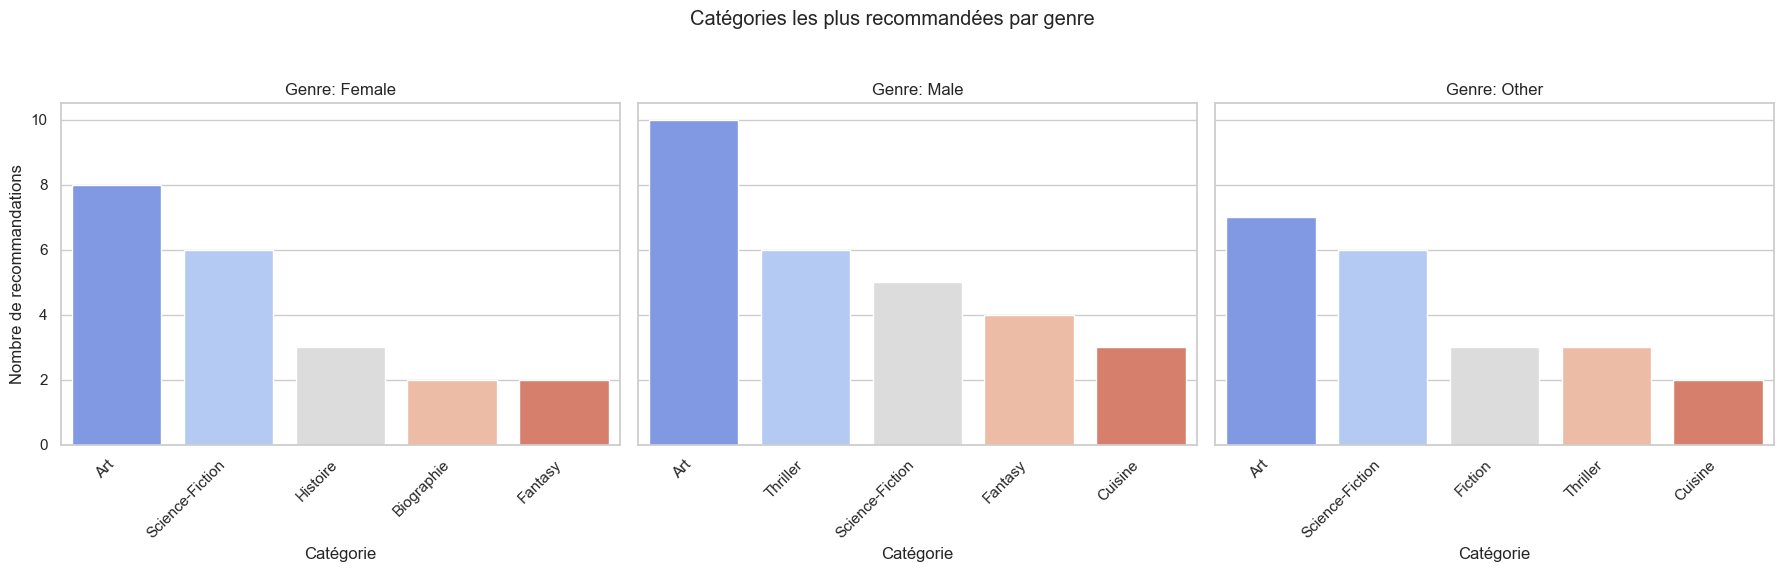

In [26]:
# Pour visualiser les catégories les plus recommandées par segment, nous devons d'abord générer des recommandations pour chaque utilisateur.
# Nous allons nous concentrer sur un segment simple, par exemple 'Gender' ou 'Age Group'.

# Créer des groupes d'âge pour une meilleure segmentation
user_profiles_df_cleaned['AgeGroup'] = pd.cut(
    user_profiles_df_cleaned['Age'],
    bins=[18, 30, 45, 65],
    labels=['18-29', '30-44', '45-64'],
    right=False
)

# Collecter les recommandations pour chaque utilisateur et chaque segment
recommendations_data = []

for user_id in user_profiles_df_cleaned['UserID']:
    user_segment_gender = user_profiles_df_cleaned.loc[user_profiles_df_cleaned['UserID'] == user_id, 'Gender'].iloc[0]
    user_segment_age_group = user_profiles_df_cleaned.loc[user_profiles_df_cleaned['UserID'] == user_id, 'AgeGroup'].iloc[0]

    # Obtenir les suggestions personnalisées (nous pouvons choisir une des méthodes, ici la principale)
    suggestions = re_engine.get_personalized_suggestions(user_id, num_suggestions=1) # Prendre la top 1 suggestion pour la simplicité

    if suggestions:
        # Extraire la catégorie du livre de la suggestion (simpliste, à adapter si les formats de suggestions varient)
        # Exemple: 'Livre de Fiction' -> 'Fiction'
        recommended_category = suggestions[0].replace('Livre de ', '').replace('Livre populaire de ', '').split(':')[0].strip()
        if 'similaire' in recommended_category:
             # Handle cases like 'Livre similaire à vos récents purchases en Fiction'
            try:
                recommended_category = recommended_category.split('en ')[1].strip()
            except IndexError:
                recommended_category = 'Autre'
        if 'spéciale' in recommended_category: # Pour la suggestion spéciale pour les âgés
            recommended_category = 'Biographie/Histoire Spéciale'

        recommendations_data.append({
            'UserID': user_id,
            'Gender': user_segment_gender,
            'AgeGroup': user_segment_age_group,
            'RecommendedCategory': recommended_category
        })

recommended_df = pd.DataFrame(recommendations_data)

# Compter les catégories recommandées par groupe d'âge
recommended_by_age_group = recommended_df.groupby('AgeGroup')['RecommendedCategory'].value_counts().unstack(fill_value=0)

# Afficher les top N recommandations par groupe d'âge
fig, axes = plt.subplots(1, len(recommended_by_age_group.index), figsize=(18, 6), sharey=True)
fig.suptitle('Catégories les plus recommandées par groupe d\'âge')

for i, (age_group, data) in enumerate(recommended_by_age_group.iterrows()):
    top_categories = data.nlargest(5) # Top 5 pour chaque groupe d'âge
    sns.barplot(x=top_categories.index, y=top_categories.values, ax=axes[i], palette='coolwarm', hue=top_categories.index, legend=False) # Modified
    axes[i].set_title(f'Groupe d\'âge: {age_group}')
    axes[i].set_xlabel('Catégorie')
    axes[i].set_xticks(range(len(top_categories.index))) # Added
    axes[i].set_xticklabels(top_categories.index, rotation=45, ha='right')
    if i == 0:
        axes[i].set_ylabel('Nombre de recommandations')
    else:
        axes[i].set_ylabel('')

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

# Répéter pour le genre
recommended_by_gender = recommended_df.groupby('Gender')['RecommendedCategory'].value_counts().unstack(fill_value=0)

fig, axes = plt.subplots(1, len(recommended_by_gender.index), figsize=(18, 6), sharey=True)
fig.suptitle('Catégories les plus recommandées par genre')

for i, (gender, data) in enumerate(recommended_by_gender.iterrows()):
    top_categories = data.nlargest(5) # Top 5 pour chaque genre
    sns.barplot(x=top_categories.index, y=top_categories.values, ax=axes[i], palette='coolwarm', hue=top_categories.index, legend=False) # Modified
    axes[i].set_title(f'Genre: {gender}')
    axes[i].set_xlabel('Catégorie')
    axes[i].set_xticks(range(len(top_categories.index))) # Added
    axes[i].set_xticklabels(top_categories.index, rotation=45, ha='right')
    if i == 0:
        axes[i].set_ylabel('Nombre de recommandations')
    else:
        axes[i].set_ylabel('')

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()